# GRA: lion + imgnet

project = ```GRA```, host = ```chewie```, device = ```cuda:1```

## Goals:

Test these Lion extensions:

**relativistic**

On `ImageNet`

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Main

In [3]:
from optimzers import *
from test.test import *

### ImgNet32

`batch_size=1024`

In [4]:
cfg = TrainConfig(
    dataset='ImageNet32',
    batch_size=1024,
    epochs=200,
    device=device,
    data_on_device=False,
    verbose=True,
    amp=False,
)

In [5]:
lr = 1e-3
beta1 = 0.8
kws = dict(lr=lr, betas=(beta1, 0.99), use_curvature=False)


experiments = [Experiment(
    f"Rel Lion — lr={lr},b1={beta1},mass={m}",
    make_opt(RelativisticLion, mass=m, **kws),
) for m in [100]]

experiments.extend([Experiment(
    f"Adam — lr={lr},b1={b1}",
    make_opt(torch.optim.Adam, lr=1e-3, betas=(b1, 0.99)),
) for b1 in [0.8, 0.9]])

print(experiments)

[
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=100',
        opt_fn=<function make_opt.<locals>._fn at 0x78640e0544a0>
    ),
    Experiment(name='Adam — lr=0.001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x78640e0547c0>),
    Experiment(name='Adam — lr=0.001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x78640e054860>)
]

In [6]:
results = run_experiments(experiments, cfg=cfg, model_kws=dict(num_classes=1000), seeds=[0])

--- Training (ImageNet32) ---

Model: ConvNet({'num_classes': 1000}) | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/200:  Train Loss 5.0878  |  Test Acc 17.09%

Epoch    5/200:  Train Loss 3.3393  |  Test Acc 29.12%

Epoch   10/200:  Train Loss 2.9591  |  Test Acc 32.71%

...

Epoch  185/200:  Train Loss 2.3345  |  Test Acc 26.03%

Epoch  190/200:  Train Loss 2.3309  |  Test Acc 25.97%

Epoch  195/200:  Train Loss 2.3238  |  Test Acc 26.03%

Epoch  200/200:  Train Loss 2.3210  |  Test Acc 25.94%

Finished in 9826.4s

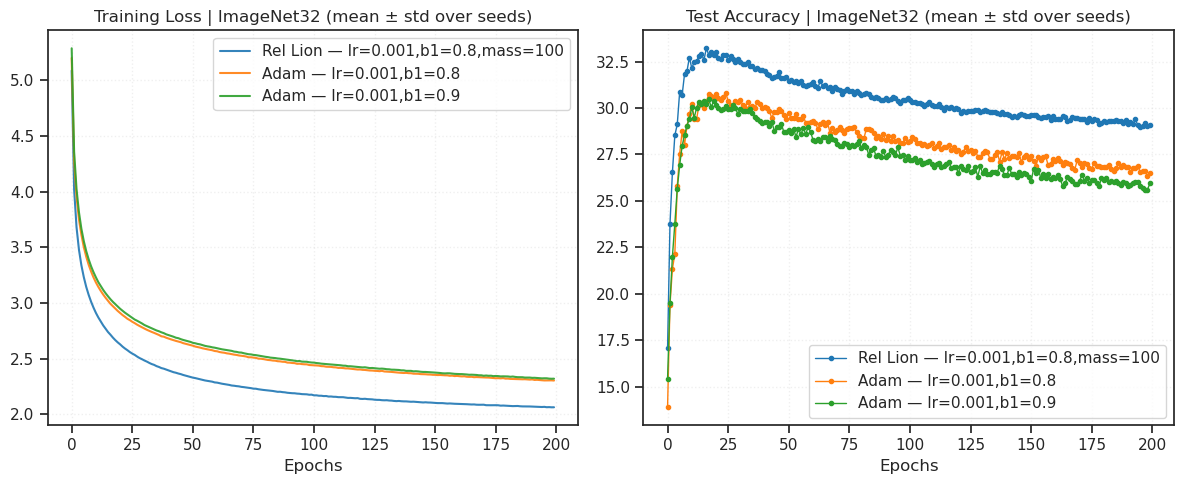

In [7]:
plot_results(results, title="ImageNet32 (mean ± std over seeds)")

In [10]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Adam — lr=0.001,b1=0.9': 25.73,
 'Adam — lr=0.001,b1=0.8': 26.54,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 29.07}

In [11]:
lr = 1e-3
beta1 = 0.8
kws = dict(lr=lr, betas=(beta1, 0.99), use_curvature=False)


experiments = [Experiment(
    f"Rel Lion — lr={lr},b1={beta1},mass={m}",
    make_opt(RelativisticLion, mass=m, **kws),
) for m in [10, 1000]]

experiments += [
    Experiment(f"Lion — lr=1e-4,b1=0.8", make_opt(Lion, lr=1e-4, betas=(0.8,0.99))),
    Experiment(f"Lion — lr=1e-4,b1=0.9", make_opt(Lion, lr=1e-4, betas=(0.9,0.99))),
    Experiment(f"Lion — lr={lr},b1=0.8", make_opt(Lion, lr=lr, betas=(0.8,0.99))),
    Experiment(f"SGD — lr={lr},b1=0.9", make_opt(torch.optim.SGD, lr=lr)),
]

print(experiments)

[
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=10',
        opt_fn=<function make_opt.<locals>._fn at 0x78640e054180>
    ),
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=1000',
        opt_fn=<function make_opt.<locals>._fn at 0x78640e057b00>
    ),
    Experiment(name='Lion — lr=1e-4,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x78640e0544a0>),
    Experiment(name='Lion — lr=1e-4,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x78640e0547c0>),
    Experiment(name='Lion — lr=0.001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x78640e054860>),
    Experiment(name='SGD — lr=0.001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x78640e057380>)
]

In [12]:
%%time


results_new = run_experiments(
    experiments,
    cfg=cfg,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ConvNet({'num_classes': 1000}) | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 10
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/200:  Train Loss 5.1279  |  Test Acc 17.55%

Epoch    5/200:  Train Loss 3.5966  |  Test Acc 28.59%

Epoch   10/200:  Train Loss 3.2762  |  Test Acc 31.45%

...

Epoch  190/200:  Train Loss 4.2071  |  Test Acc 19.86%

Epoch  195/200:  Train Loss 4.1844  |  Test Acc 19.75%

Epoch  200/200:  Train Loss 4.1605  |  Test Acc 20.14%

Finished in 9887.7s

CPU times: user 16h 45min 50s, sys: 9min 12s, total: 16h 55min 2s
Wall time: 16h 53min 17s


In [13]:
combined = results | results_new

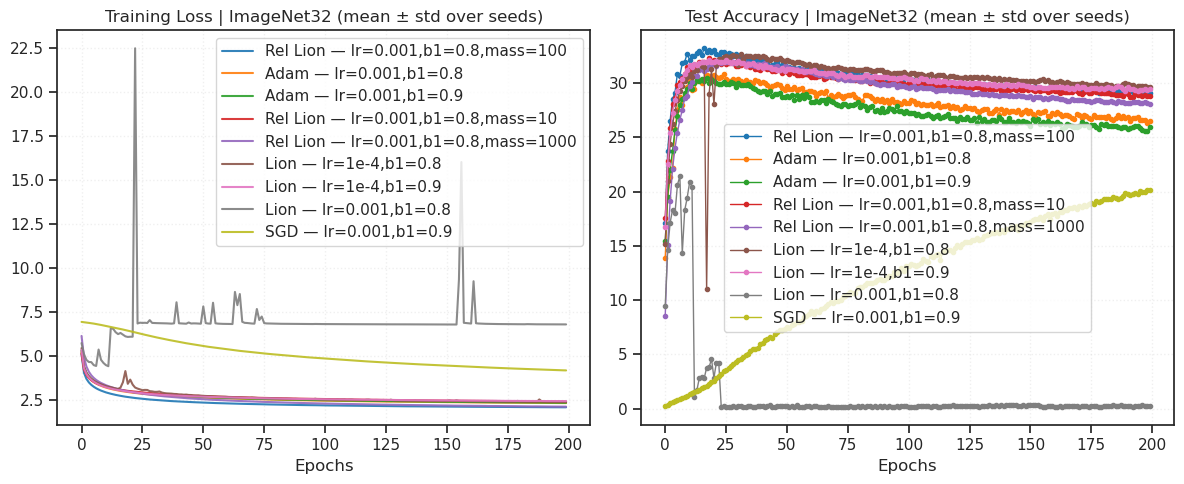

In [14]:
plot_results(combined, title="ImageNet32 (mean ± std over seeds)")

In [15]:
avg_scores = {
    k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2)
    for k, d in combined.items()
}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Lion — lr=0.001,b1=0.8': 0.27,
 'SGD — lr=0.001,b1=0.9': 20.06,
 'Adam — lr=0.001,b1=0.9': 25.73,
 'Adam — lr=0.001,b1=0.8': 26.54,
 'Rel Lion — lr=0.001,b1=0.8,mass=1000': 28.17,
 'Rel Lion — lr=0.001,b1=0.8,mass=10': 28.87,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 29.07,
 'Lion — lr=1e-4,b1=0.9': 29.41,
 'Lion — lr=1e-4,b1=0.8': 29.69}

In [19]:
import importlib

# If your module is literally named `optimzers.py`
import optimzers
importlib.reload(optimzers)
from optimzers import RelativisticSignum

In [20]:
lrs = [1e-3]
betas = [0.8, 0.9]
masses = [100]

experiments = []
for lr, beta1, m in itertools.product(lrs, betas, masses):

    name = f"Rel. Signum — lr={lr:g},b1={beta1:g},mass={m:g}"
    opt_fn = make_opt(RelativisticSignum, lr=lr, momentum=beta1, mass=m)

    experiments.append(Experiment(name=name, opt_fn=opt_fn))

len(experiments)

2

In [21]:
%%time


results_signum = run_experiments(
    experiments,
    cfg=cfg,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ConvNet({'num_classes': 1000}) | seed=0
Optimizer: RelativisticSignum

RelativisticSignum (
Parameter Group 0
    lr: 0.001
    mass: 100
    momentum: 0.8
    weight_decay: 0.0
)

Epoch    1/200:  Train Loss 6.3366  |  Test Acc 5.91%

Epoch    5/200:  Train Loss 4.3022  |  Test Acc 19.70%

Epoch   10/200:  Train Loss 3.7244  |  Test Acc 25.86%

...

Epoch  190/200:  Train Loss 2.1097  |  Test Acc 29.14%

Epoch  195/200:  Train Loss 2.1046  |  Test Acc 28.71%

Epoch  200/200:  Train Loss 2.0994  |  Test Acc 28.85%

Finished in 10136.6s

CPU times: user 5h 38min 8s, sys: 1min, total: 5h 39min 9s
Wall time: 5h 38min 34s


In [22]:
total_final_results = combined | results_signum

In [23]:
avg_scores = {
    k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2)
    for k, d in total_final_results.items()
}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Lion — lr=0.001,b1=0.8': 0.27,
 'SGD — lr=0.001,b1=0.9': 20.06,
 'Adam — lr=0.001,b1=0.9': 25.73,
 'Adam — lr=0.001,b1=0.8': 26.54,
 'Rel Lion — lr=0.001,b1=0.8,mass=1000': 28.17,
 'Rel. Signum — lr=0.001,b1=0.8,mass=100': 28.8,
 'Rel. Signum — lr=0.001,b1=0.9,mass=100': 28.83,
 'Rel Lion — lr=0.001,b1=0.8,mass=10': 28.87,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 29.07,
 'Lion — lr=1e-4,b1=0.9': 29.41,
 'Lion — lr=1e-4,b1=0.8': 29.69}

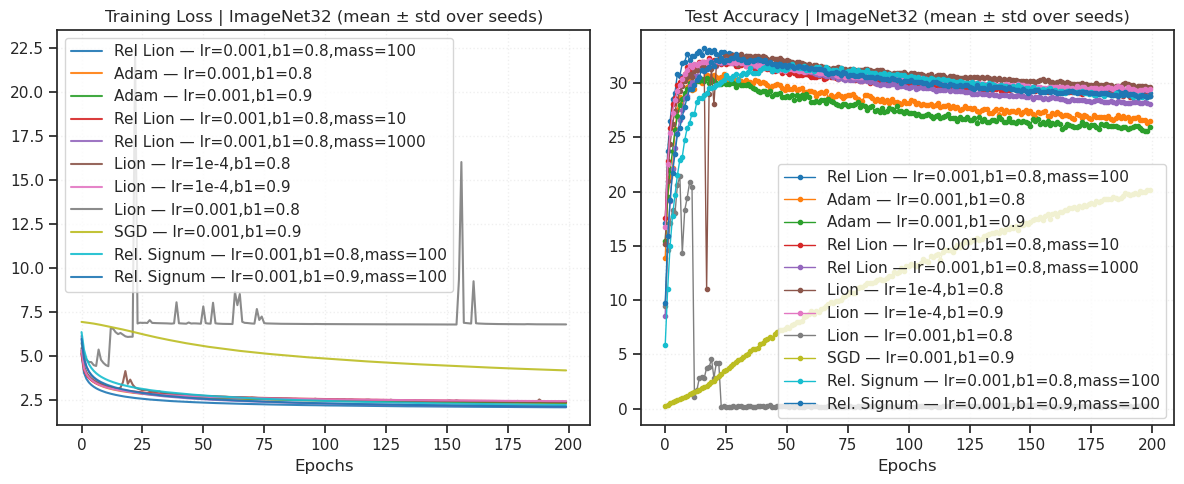

In [24]:
plot_results(total_final_results, title="ImageNet32 (mean ± std over seeds)")